Using device: cpu
Images found: 3095

Extracting CNN features...
0/3095 images processed
200/3095 images processed
400/3095 images processed
600/3095 images processed
800/3095 images processed
1000/3095 images processed
1200/3095 images processed
1400/3095 images processed
1600/3095 images processed
1800/3095 images processed
2000/3095 images processed
2200/3095 images processed
2400/3095 images processed
2600/3095 images processed
2800/3095 images processed
3000/3095 images processed
Feature extraction finished

Training MIL model
Epoch 1  Loss: 0.2235
Epoch 2  Loss: 0.2001
Epoch 3  Loss: 0.1965
Epoch 4  Loss: 0.1927
Epoch 5  Loss: 0.1883
Epoch 6  Loss: 0.1838
Epoch 7  Loss: 0.1791
Epoch 8  Loss: 0.1738

Training finished
Prediction: tensor([[0.9629, 0.0371]])


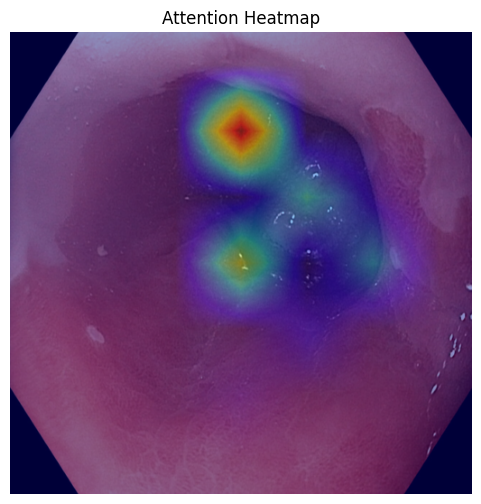

In [8]:
# ==========================================
# GastroNet + Attention MIL
# ==========================================

import os
import random
from glob import glob
from PIL import Image

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models


# ==========================================
# Configuration
# ==========================================

DATA_ROOT = r"C:\Users\tkorz\OneDrive\Documents\Masters-tkorzhan\Q3\Team internship\dataset\train_anoniem"

IMG_SIZE = 512
PATCH_SIZE = 128
STRIDE = 64

EPOCHS = 8
LEARNING_RATE = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# Dataset Loader
# ==========================================

class BarrettDataset:

    def __init__(self, root, transform):

        self.samples = []
        label_map = {"ndbe": 0, "neo": 1}

        for center in ["center_1", "center_2"]:
            for cls in label_map:

                folder = os.path.join(root, center, cls)

                if not os.path.isdir(folder):
                    continue

                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    files = glob(os.path.join(folder, ext))

                    for f in files:
                        self.samples.append((f, label_map[cls]))

        self.transform = transform
        print("Images found:", len(self.samples))


    def __len__(self):
        return len(self.samples)


    def get(self, idx):

        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")
        img = self.transform(img)

        return img, label, path


# ==========================================
# Image Preprocessing
# ==========================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = BarrettDataset(DATA_ROOT, transform)


# ==========================================
# Patch Extraction with Circular Mask
# ==========================================

def extract_patches(img_tensor):

    patches = F.unfold(
        img_tensor,
        kernel_size=PATCH_SIZE,
        stride=STRIDE
    )

    patches = patches.transpose(1, 2)
    patches = patches.reshape(-1, 3, PATCH_SIZE, PATCH_SIZE)

    grid = int((IMG_SIZE - PATCH_SIZE) / STRIDE + 1)

    center = IMG_SIZE / 2
    radius = IMG_SIZE / 2

    valid_patches = []
    coords = []

    idx = 0

    for y in range(grid):
        for x in range(grid):

            patch = patches[idx]

            px = x * STRIDE + PATCH_SIZE / 2
            py = y * STRIDE + PATCH_SIZE / 2

            dist = ((px - center) ** 2 + (py - center) ** 2) ** 0.5

            if dist < radius * 0.9:
                valid_patches.append(patch)
                coords.append((x, y))

            idx += 1

    patches = torch.stack(valid_patches)

    return patches, coords, grid


# ==========================================
# CNN Feature Extractor
# ==========================================

class FeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        self.features = nn.Sequential(*list(backbone.children())[:-1])


    def forward(self, x):

        with torch.no_grad():
            x = self.features(x)

        x = x.view(x.size(0), -1)
        x = F.normalize(x)

        return x


extractor = FeatureExtractor().to(device)


# ==========================================
# Extract CNN Features
# ==========================================

features = []
labels = []
grids = []
coords_list = []
images = []

print("\nExtracting CNN features...")

for i in range(len(dataset)):

    img, label, path = dataset.get(i)

    img_tensor = img.unsqueeze(0).to(device)

    patches, coords, grid = extract_patches(img_tensor)

    feats = extractor(patches)

    features.append(feats.cpu())
    labels.append(label)
    grids.append(grid)
    coords_list.append(coords)
    images.append(img)

    if i % 200 == 0:
        print(f"{i}/{len(dataset)} images processed")

print("Feature extraction finished")


# ==========================================
# Attention MIL Model
# ==========================================

class AttentionMIL(nn.Module):

    def __init__(self, feature_dim):

        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Linear(feature_dim, 2)


    def forward(self, feats):

        A = self.attention(feats)
        A = torch.softmax(A.squeeze(-1) / 0.5, dim=0)

        M = torch.sum(A.unsqueeze(-1) * feats, dim=0)

        logits = self.classifier(M.unsqueeze(0))

        return logits, A


model = AttentionMIL(features[0].shape[1]).to(device)


# ==========================================
# Training
# ==========================================

class_weights = torch.tensor([0.4, 0.6]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("\nTraining MIL model")

indices = list(range(len(features)))

for epoch in range(EPOCHS):

    random.shuffle(indices)

    total_loss = 0

    for idx in indices:

        feats = features[idx].to(device)
        label = torch.tensor([labels[idx]]).to(device)

        logits, _ = model(feats)

        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}  Loss: {total_loss/len(features):.4f}")

print("\nTraining finished")


# ==========================================
# Heatmap Reconstruction
# ==========================================

def build_heatmap(attn, coords, grid):

    heat = torch.zeros(grid, grid)

    for i, (x, y) in enumerate(coords):
        heat[y, x] = attn[i]

    heat = heat.unsqueeze(0).unsqueeze(0)

    heat = F.interpolate(
        heat,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )

    heat = heat.squeeze()

    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-6)

    return heat


# ==========================================
# Example Prediction
# ==========================================

model.eval()

feats = features[0].to(device)

with torch.no_grad():
    logits, attn = model(feats)

probs = torch.softmax(logits, dim=1).cpu()

print("Prediction:", probs)

heat = build_heatmap(attn.cpu(), coords_list[0], grids[0])


# ==========================================
# Visualization
# ==========================================

img = images[0].clone()

img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)

img = img.permute(1,2,0).numpy()

plt.figure(figsize=(6,6))

plt.imshow(img)
plt.imshow(heat.numpy(), cmap="jet", alpha=0.45)

plt.title("Attention Heatmap")
plt.axis("off")

plt.show()

The smooth attention heatmap overlays the model’s attention distribution on the original endoscopic image. High-intensity regions (red/yellow) correspond to areas that contribute most strongly to the model’s prediction, while low-intensity regions (blue/purple) indicate minimal influence. The heatmap shows a prominent activation in the lower central portion of the image, indicating that the model primarily relies on visual features in this region. Attention gradually decreases toward the peripheral regions of the frame.

The heatmap shows which image regions influenced the model’s prediction most.

Color meaning:

Color	Meaning
🔴 Red	Highest model attention (most important features)
🟡 Yellow	High importance
🟢 Green	Moderate importance
🔵 Blue	Low importance
⚫ Dark / none	Almost no contribution

heatmap shows two main attention hotspots:
Upper central mucosal wall (red)
Lower central mucosal region (yellow/green)

The attention heatmap visualizes the spatial regions that contributed most strongly to the model’s prediction. Warmer colors (red/yellow) indicate areas of higher attention, while cooler colors (blue) correspond to regions with lower influence. The model focuses primarily on mucosal tissue regions within the endoscopic field, suggesting that it relies on local texture and structural patterns for classification rather than border artifacts.

The model is focusing on:

mucosal texture patterns

surface irregularities

regions with different color/contrast

These are exactly the types of cues clinicians use to detect Barrett dysplasia or early neoplasia.

So the model is likely detecting:

subtle mucosal structure differences

vascular pattern variation

texture contrast

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)--> learning rate is not too high
In Barrett datasets typically:
ndbe: ~80–90%
neo: ~10–20%
Without weighting, the model learns:
"predict normal most of the time"

The following pre-processing steps performed: 
ImageNet normalization for ResNet18

Border patch filtering (removes black border patches)

Dropout in MIL attention head


Add class weights:criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([0.4,0.6]).to(device)

Cleaner patch extraction with patch filtering

Stable heatmap normalization

Small training stability improvements




MIL models work like this:

image → patches → CNN features → attention weights

The attention layer selects:

patches most informative for classification

So instead of highlighting the entire lesion, it often highlights several discriminative patches.